In [87]:
import pandas as pd

# File paths (UCSC Xena BRCA datasets)
gistic_copynumber = '/Users/erickgaldamezcalles/Desktop/UCSC Xena datasets/Breast/TCGA.BRCA.sampleMap_Gistic2_CopyNumber_Gistic2_all_data_by_genes.gz'
tcga_brca_hiseqv2 = '/Users/erickgaldamezcalles/Desktop/UCSC Xena datasets/Breast/TCGA.BRCA.sampleMap_HiSeqV2'

# Load raw datasets (genes × samples format)
cnv_raw = pd.read_csv(gistic_copynumber, sep="\t", low_memory=False)
expr_raw = pd.read_csv(tcga_brca_hiseqv2, sep="\t", low_memory=False)

print("cnv_raw shape:", cnv_raw.shape)
print("expr_raw shape:", expr_raw.shape)

cnv_raw shape: (24776, 1081)
expr_raw shape: (20530, 1219)


In [88]:
# Convert to samples × genes format
# First column contains gene names → set as index, then transpose
cnv = cnv_raw.set_index(cnv_raw.columns[0]).T
expr = expr_raw.set_index(expr_raw.columns[0]).T

print("cnv shape:", cnv.shape)
print("expr shape:", expr.shape)

# Confirm ERBB2 exists
print("ERBB2 in expr columns?", "ERBB2" in expr.columns)

cnv shape: (1080, 24776)
expr shape: (1218, 20530)
ERBB2 in expr columns? True


In [89]:
# Find shared samples between CNV and expression datasets
common_samples = expr.index.intersection(cnv.index)
print("common samples:", len(common_samples))

common samples: 1078


In [ ]:
# Subset both datasets to shared samples
X_brca = cnv.loc[common_samples].copy()
y_brca = expr.loc[common_samples, "ERBB2"].copy()

print("X_brca:", X_brca.shape)
print("y_brca:", y_brca.shape)
print(y_brca.head())

X_brca: (1078, 24776)
y_brca: (1078,)
TCGA-AR-A5QQ-01    10.9073
TCGA-D8-A1JA-01    15.8848
TCGA-BH-A0BQ-01    13.4812
TCGA-BH-A0BT-01    13.9334
TCGA-A8-A06X-01    12.9645
Name: ERBB2, dtype: float64


In [ ]:
# Ensure all values are numeric
X_brca = X_brca.apply(pd.to_numeric, errors="coerce")
y_brca = pd.to_numeric(y_brca, errors="coerce")

#confirm there is no missing/null values in X and y
print("Missing in X:", X_brca.isna().sum().sum())
print("Missing in y:", y_brca.isna().sum())

Missing in X: 0
Missing in y: 0


In [ ]:
# Remove samples with missing target values
valid = y_brca.notna()
X_brca = X_brca.loc[valid].fillna(0)
y_brca = y_brca.loc[valid]

In [ ]:
# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_brca, y_brca, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(862, 24776) (216, 24776) (862,) (216,)


In [97]:
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
"""
Elastic Net is used because:
- L1 (lasso) performs feature selection
- L2 (ridge) stabilizes correlated genomic features (CNV regions)
"""
enet_cv = make_pipeline(
    StandardScaler(),
    ElasticNetCV(
        l1_ratio=[0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-2, 1, 8),
        cv=5,
        max_iter=50000,
        tol=1e-3,
        n_jobs=-1
    )
)
# Train model
enet_cv.fit(X_train, y_train)

# Predict on test set
pred_cv = enet_cv.predict(X_test)

# Performance metrics
rmse = np.sqrt(mean_squared_error(y_test, pred_cv))
mae = mean_absolute_error(y_test, pred_cv)
r2 = r2_score(y_test, pred_cv)

print("Best alpha:", enet_cv.named_steps["elasticnetcv"].alpha_)
print("Best l1_ratio:", enet_cv.named_steps["elasticnetcv"].l1_ratio_)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

Best alpha: 0.07196856730011521
Best l1_ratio: 0.7
RMSE: 0.8259484932516566
MAE: 0.5850659646101355
R2: 0.6864737676250913


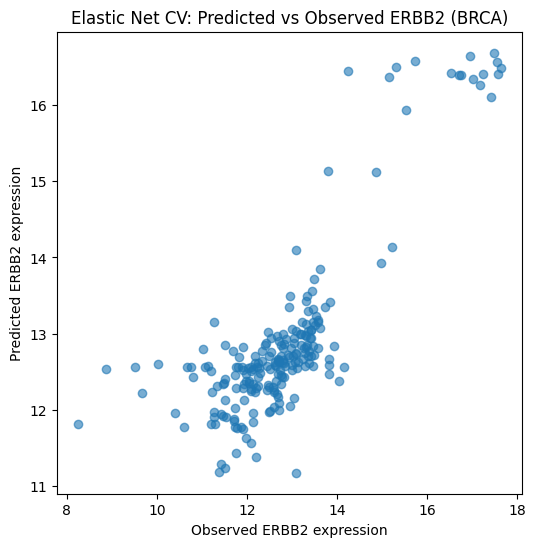

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_cv, alpha=0.6)
plt.xlabel("Observed ERBB2 expression")
plt.ylabel("Predicted ERBB2 expression")
plt.title("Elastic Net CV: Predicted vs Observed ERBB2 (BRCA)")
plt.show()

In [99]:
best_enet = enet_cv.named_steps["elasticnetcv"]
coefs = pd.Series(best_enet.coef_, index=X_brca.columns)

top_features = coefs.abs().sort_values(ascending=False).head(20)
print(top_features)
print(coefs.loc[top_features.index])

Gene Symbol
ERBB2                         0.190713
PGAP3                         0.179438
NEUROD2                       0.158967
STARD3                        0.157091
MIEN1                         0.134677
MIR4728                       0.129309
TCAP                          0.122121
PNMT                          0.117014
ELF5                          0.053924
NUP93                         0.048711
SNORD112|ENSG00000252572.1    0.039953
PSMD3                         0.039468
COX6A1P2                      0.034928
GLS                           0.029577
ST6GALNAC3                    0.025645
RN7SL69P                      0.025159
C8orf46                       0.022561
GFOD2                         0.021951
IRF2                          0.021639
FGD2                          0.020214
dtype: float64
Gene Symbol
ERBB2                         0.190713
PGAP3                         0.179438
NEUROD2                       0.158967
STARD3                        0.157091
MIEN1                    